In [10]:
import json
import csv
import pickle
import numpy as np
import matplotlib.pyplot as plt
import xgi
# disgenenet, always encountered devision by 0, something finiky here

plt.style.use('seaborn-v0_8-whitegrid')

def expectation(x):
    
    to_sum = [(i)*j for i,j in enumerate(x)]
      
    return sum(to_sum)

realworld_Hgraphs = ["coauth-dblp", "coauth-mag-geology", "coauth-mag-history", "dawn", "disgenenet",
                     "diseasome", "kaggle-whats-cooking", "ndc-classes", "ndc-substances",
                     "tags-ask-ubuntu", "tags-math-sx" , "tags-stack-overflow", "threads-ask-ubuntu", 
                     "threads-math-sx", "threads-stack-overflow",
                     "congress-bills", "contact-high-school", "contact-primary-school",
                     "email-enron", "email-eu", "hospital-lyon", "hypertext-conference", 
                     "invs13", "invs15",  "malawi-village", "science-gallery", "sfhh-conference"]



num_nodes = ["1,930,378", "1,261,129", "1,034,876", "2,558", "12,368", "516", "6,714", "1,161", "5,556",
            "3,029", "1,629", "49,998", "125,602", "176,445", "2,675,969",
            "1,718", "327", "242", "148", "1,005", "75", "113", "92", "232", "86", "10,972", "403"]

num_edges = ["3,700,681", "1,590,335", "1,812,511", "2,272,433", "2,261", "903", "39,774", "49,726", "112,405",
            "271,233", "822,059", "14,458,875", "192,947", "719,792", "11,305,356",
            "282,049", "172,035", "106,879", "10,885", "235,263", "27,834", "19,036",
            "9,644", "73,822", "99,942", "338,765", "54,305"]

#"dawn"
# "tags-stack-overflow"




data_type_dict    = {"coauth-dblp": "co-author", 
                     "coauth-mag-geology": "co-author",
                     "coauth-mag-history": "co-author", 
                     "congress-bills": "social", 
                     "contact-high-school": "social",
                     "contact-primary-school": "social",
                     "dawn": "biological",
                     "diseasome": "biological", 
                     "disgenenet": "biological",
                     "email-enron": "social", 
                     "email-eu": "social",
                     "hospital-lyon": "social",
                     "hypertext-conference": "social",
                     "invs13": "social", 
                     "invs15": "social", 
                     "kaggle-whats-cooking": "biological", 
                     "malawi-village": "social",
                     "ndc-classes": "biological",
                     "ndc-substances": "biological", 
                     "science-gallery": "social", 
                     "sfhh-conference": "social",
                     "tags-ask-ubuntu": "webpage", 
                     "tags-math-sx": "webpage",
                     "tags-stack-overflow": "webpage",
                     "threads-ask-ubuntu": "webpage",
                     "threads-math-sx": "webpage", 
                     "threads-stack-overflow": "webpage"}

nontemporal = ["disgenenet", "hypertext-conference", "invs13", "invs15", 
               "kaggle-whats-cooking", "malawi-village", "science-gallery", "sfhh-conference"]
temporal = list(set(realworld_Hgraphs)-set(nontemporal))

mymarkers = ["o", "v","^","<",">","1","2","3","4","s","p","P","*","h","H","+","x","X","D","d"]


data_type_color = {"co-author": "sandybrown", 
                   "social": "cornflowerblue",
                  "biological": "palevioletred",
                  "webpage": "olivedrab"}

data_marker_dict    = {"coauth-dblp": "o", 
                     "coauth-mag-geology": "v",
                     "coauth-mag-history": "^", 
                     "congress-bills": "o", 
                     "contact-high-school": "v",
                     "contact-primary-school": "^",
                     "diseasome": "o", 
                     "dawn": ">",
                     "disgenenet": "1", 
                     "email-enron": "<", 
                     "email-eu": ">",
                     "hospital-lyon": "*",
                     "hypertext-conference": "D",
                     "invs13": "d", 
                     "invs15": "H", 
                     "kaggle-whats-cooking": "v", 
                     "malawi-village": "s",
                     "ndc-classes": "^",
                     "ndc-substances": "<", 
                     "science-gallery": "p", 
                     "sfhh-conference": "P",
                     "tags-ask-ubuntu": "o", 
                     "tags-math-sx": "v",
                     "tags-stack-overflow": "^",
                     "threads-ask-ubuntu": "<",
                     "threads-math-sx": ">", 
                     "threads-stack-overflow": "1"}

In [11]:
# ## code to read in and output CSV files


print("dataset", "&", "eta", "&",  "beta", "&", "gamma", r"\\" )
ETA = []
BETA = []
GAMMA = []

with open('figures/parameters.csv','w', newline='') as file:

    writer = csv.writer(file)
    
    writer.writerow(["dataset", "eta", "beta", "gamma"])
    #for data_name in ["email-enron"]:
    for data_name in realworld_Hgraphs:
        
        try:
            with open('sem_results_new/res_{}.pkl'.format(data_name + "_SEM_new"), "rb") as f:
                d = pickle.load(f)

            print(d["dataset"],"&",  round(np.mean(d["eta"][-50:]),3),"&",  round(expectation(np.mean(d["beta"][-50:], axis=0)), 3), "&", round(expectation(np.mean(d["gamma"][-50:], axis=0)), 3), r"\\")

            writer.writerow([d["dataset"],  round(np.mean(d["eta"][-50:]),3), round(expectation(np.mean(d["beta"][-50:], axis=0)), 3),  round(expectation(np.mean(d["gamma"][-50:], axis=0)), 3)])
            ETA.append(round(np.mean(d["eta"][-50:]),3))
            BETA.append( round(expectation(np.mean(d["beta"][-50:], axis=0)), 3))   
            GAMMA.append(round(expectation(np.mean(d["gamma"][-50:], axis=0)), 3))


        except:
            print("not finished")






dataset & eta & beta & gamma \\
coauth-dblp & 0.506 & 0.391 & 0.517 \\
coauth-mag-geology & 0.376 & 0.551 & 0.634 \\
coauth-mag-history & 0.256 & 0.163 & 0.095 \\
dawn & 0.723 & 0.001 & 0.086 \\
disgenenet & 0.089 & 0.001 & 6.995 \\
diseasome & 0.079 & 0.003 & 0.53 \\
kaggle-whats-cooking & 0.4 & 0.168 & 4.837 \\
ndc-classes & 0.988 & 0.013 & 0.021 \\
ndc-substances & 0.735 & 0.02 & 0.125 \\
tags-ask-ubuntu & 0.598 & 0.011 & 0.554 \\
tags-math-sx & 0.774 & 0.003 & 0.181 \\
tags-stack-overflow & 0.771 & 0.003 & 0.371 \\
threads-ask-ubuntu & 0.063 & 0.461 & 0.483 \\
threads-math-sx & 0.17 & 0.204 & 0.875 \\
threads-stack-overflow & 0.083 & 0.174 & 1.038 \\
congress-bills & 0.322 & 0.009 & 1.823 \\
contact-high-school & 0.965 & 0.002 & 0.041 \\
contact-primary-school & 0.911 & 0.003 & 0.11 \\
email-enron & 0.881 & 0.013 & 0.13 \\
email-eu & 0.907 & 0.003 & 0.104 \\
hospital-lyon & 0.958 & 0.002 & 0.064 \\
hypertext-conference & 0.882 & 0.002 & 0.12 \\
invs13 & 0.927 & 0.002 & 0.075 \\
inv

In [6]:
print("dataset", "&", r"$\eta$", "&",  r"$\beta$", "&", r"$\gamma$", r"\\" )
for data_name in realworld_Hgraphs:

    try:
        with open('sem_results_new/res_{}.pkl'.format(data_name + "_SEM_new"), "rb") as f:
            d = pickle.load(f)

        print(d["dataset"],"&",  round(np.mean(d["eta"][-50:]),3),"&",  round(np.mean(d["beta"][-50:]),3), "&", round(expectation(np.mean(d["gamma"][-50:], axis=0)), 3), r"\\")
        
        
    except:
        pass

dataset & $\eta$ & $\beta$ & $\gamma$ \\
coauth-dblp & 0.506 & 0.1 & 0.517 \\
coauth-mag-geology & 0.376 & 0.1 & 0.634 \\
coauth-mag-history & 0.256 & 0.1 & 0.095 \\
dawn & 0.723 & 0.1 & 0.086 \\
disgenenet & 0.089 & 0.094 & 6.995 \\
diseasome & 0.079 & 0.1 & 0.53 \\
kaggle-whats-cooking & 0.4 & 0.1 & 4.837 \\
ndc-classes & 0.988 & 0.1 & 0.021 \\
ndc-substances & 0.735 & 0.1 & 0.125 \\
tags-ask-ubuntu & 0.598 & 0.1 & 0.554 \\
tags-math-sx & 0.774 & 0.1 & 0.181 \\
tags-stack-overflow & 0.771 & 0.1 & 0.371 \\
threads-ask-ubuntu & 0.063 & 0.1 & 0.483 \\
threads-math-sx & 0.17 & 0.1 & 0.875 \\
threads-stack-overflow & 0.083 & 0.1 & 1.038 \\
congress-bills & 0.322 & 0.1 & 1.823 \\
contact-high-school & 0.965 & 0.1 & 0.041 \\
contact-primary-school & 0.911 & 0.1 & 0.11 \\
email-enron & 0.881 & 0.1 & 0.13 \\
email-eu & 0.907 & 0.1 & 0.104 \\
hospital-lyon & 0.958 & 0.1 & 0.064 \\
hypertext-conference & 0.882 & 0.1 & 0.12 \\
invs13 & 0.927 & 0.1 & 0.075 \\
invs15 & 0.936 & 0.1 & 0.071 \\
malaw

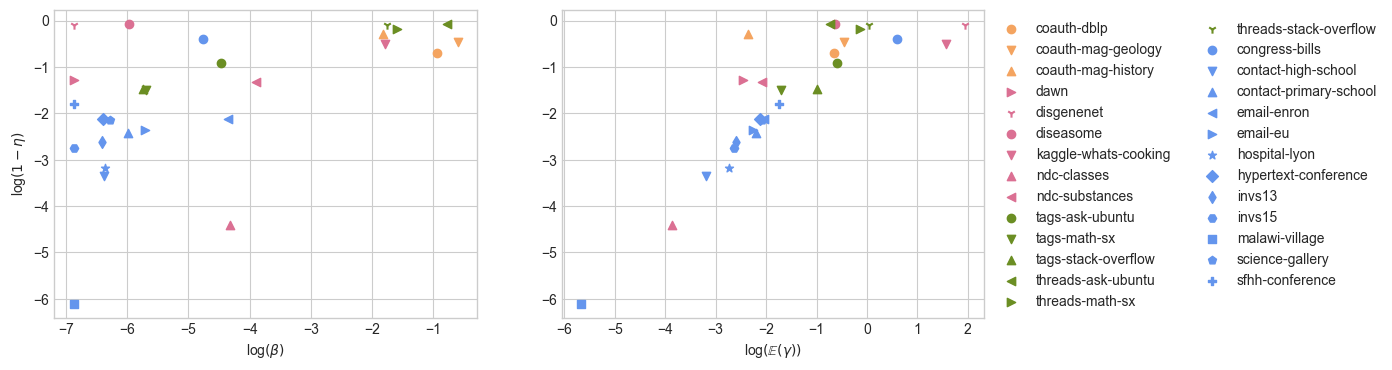

In [7]:
ETA = []
BETA = []
GAMMA = []

for data_name in realworld_Hgraphs:


    with open('sem_results_new/res_{}.pkl'.format(data_name + "_SEM_new"), "rb") as f:
        d = pickle.load(f)

    ETA.append(np.mean(d["eta"][-50:]))
    BETA.append(expectation(np.mean(d["beta"][-50:], axis=0)))   
    GAMMA.append(expectation(np.mean(d["gamma"][-50:], axis=0)))



fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))
#ax.scatter(BETA, ETA)

for i, txt in enumerate(realworld_Hgraphs):
    ax[0].scatter(np.log(BETA[i]), np.log(1-ETA[i]), 
               marker= data_marker_dict[txt], 
               color = data_type_color[data_type_dict[txt]],
               label = txt)
    #print(BETA[i], np.log(BETA[i]))

    
for i, txt in enumerate(realworld_Hgraphs):
    ax[1].scatter(np.log(GAMMA[i]),np.log(1-ETA[i]), 
               marker= data_marker_dict[txt], 
               color = data_type_color[data_type_dict[txt]],
               label = txt)
    #print(GAMMA[i], np.log(GAMMA[i]))

ax[0].set_xlabel(r"log$(\beta)$")
ax[0].set_ylabel(r"log$(1-\eta)$")
ax[1].set_xlabel(r"log$(\mathbb{E}(\gamma))$")
#ax[1].set_ylabel("ETA")
ax[1].legend(ncol = 2,fontsize=10,  bbox_to_anchor=(1,1))

#ax.set_xscale('log')
#ax.set_title("$\beta$ against $\eta$ ratio")
plt.savefig("figures/PARAMETERS.pdf",bbox_inches='tight')

In [9]:
## code to print the link prediction results for the new model
# For the Randomized Draws, i.e. not temporailiry dependent assumption. 

print("dataset","&",  "Type", "&", "Num of Nodes","&", "Num of Edges" , "&", "AUC", "&",  "REC", "&", "F1",
      "&", "AUC (temporal)", "&",  "REC (temporal)", "&", "F1 (temporal)", r"\\" )

incomplete = []

incomplete_random = []

for xx, data_name in enumerate(realworld_Hgraphs):

    H_type = data_type_dict[data_name]
    
    AUC = []
    REC = []
    F1_ = []

    AUC_temporal = []
    REC_temporal = []
    F1__temporal = []

    for jj in range(10):
        try:
            with open('lp_100k_random/{}_trainOnly_{}.pkl'.format(data_name, jj), 'rb') as f:
                d = pickle.load(f)
            #print(d)
            AUC.append(d["AUC"])
            REC.append(d["recall"])
            F1_.append(d["f1"])
        
        except:
            incomplete_random.append((data_name, jj))
            
    for jj in range(1):
        try:
            with open('lp_100k_temporal/{}_trainOnly_{}.pkl'.format(data_name, jj), 'rb') as f:
                d = pickle.load(f)
            #print(d)
            AUC_temporal.append(d["AUC"])
            REC_temporal.append(d["recall"])
            F1__temporal.append(d["f1"])

        except:
            incomplete.append((data_name, jj))
    


    if data_name in temporal:
    

        print(data_name, "&", H_type, "&", num_nodes[xx], "&", num_edges[xx], "&",  
              format(np.mean(AUC),'.3f'),"&",  format(np.mean(REC),'.3f'), 
              "&", format(np.mean(F1_),'.3f'), "&",
              format(np.mean(AUC_temporal),'.3f'),"&",  format(np.mean(REC_temporal),'.3f'), 
              "&", format(np.mean(F1__temporal),'.3f'), r"\\")

        
        
        
    
    else:
    
        print(data_name, "&", H_type, "&", num_nodes[xx], "&", num_edges[xx], "&",  
              round(np.mean(AUC),3),"&",  round(np.mean(REC),3), "&", round(np.mean(F1_),3), "&",
              "NA","&",  "NA", "&", "NA", r"\\")





dataset & Type & Num of Nodes & Num of Edges & AUC & REC & F1 & AUC (temporal) & REC (temporal) & F1 (temporal) \\
coauth-dblp & co-author & 1,930,378 & 3,700,681 & 0.872 & 0.807 & 0.807 & 0.693 & 0.747 & 0.747 \\
coauth-mag-geology & co-author & 1,261,129 & 1,590,335 & 0.783 & 0.670 & 0.670 & 0.574 & 0.657 & 0.657 \\
coauth-mag-history & co-author & 1,034,876 & 1,812,511 & 0.635 & 0.606 & 0.605 & 0.343 & 0.454 & 0.453 \\
dawn & biological & 2,558 & 2,272,433 & nan & nan & nan & nan & nan & nan \\
disgenenet & biological & 12,368 & 2,261 & 0.613 & 0.569 & 0.569 & NA & NA & NA \\
diseasome & biological & 516 & 903 & 0.470 & 0.460 & 0.456 & 0.549 & 0.590 & 0.590 \\
kaggle-whats-cooking & biological & 6,714 & 39,774 & 0.949 & 0.909 & 0.909 & NA & NA & NA \\
ndc-classes & biological & 1,161 & 49,726 & 0.988 & 0.963 & 0.962 & 0.988 & 0.970 & 0.970 \\
ndc-substances & biological & 5,556 & 112,405 & 0.554 & 0.546 & 0.546 & 0.618 & 0.618 & 0.617 \\
tags-ask-ubuntu & webpage & 3,029 & 271,233 &

C:\Users\hexie\.conda\envs\Hgraph\lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\hexie\.conda\envs\Hgraph\lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [7]:
import pickle

with open("incomplete_random.lst", "wb") as fp:   
    pickle.dump(incomplete_random, fp)
    
# with open("incomplete.lst", "wb") as fp:   
#     pickle.dump(incomplete, fp)


In [10]:
print(len(incomplete_random))
print(incomplete_random)

33
[('diseasome', 4), ('kaggle-whats-cooking', 2), ('kaggle-whats-cooking', 3), ('ndc-substances', 4), ('tags-stack-overflow', 0), ('tags-stack-overflow', 1), ('tags-stack-overflow', 2), ('tags-stack-overflow', 3), ('tags-stack-overflow', 4), ('tags-stack-overflow', 5), ('tags-stack-overflow', 6), ('tags-stack-overflow', 7), ('tags-stack-overflow', 8), ('tags-stack-overflow', 9), ('congress-bills', 0), ('congress-bills', 5), ('contact-high-school', 3), ('contact-primary-school', 0), ('contact-primary-school', 2), ('email-enron', 1), ('email-eu', 9), ('hospital-lyon', 6), ('hypertext-conference', 5), ('invs13', 4), ('invs13', 7), ('invs15', 5), ('malawi-village', 1), ('malawi-village', 5), ('malawi-village', 8), ('science-gallery', 1), ('science-gallery', 2), ('sfhh-conference', 3), ('sfhh-conference', 9)]


In [11]:
print(len(incomplete))
print(incomplete)

52
[('diseasome', 0), ('diseasome', 1), ('diseasome', 2), ('diseasome', 3), ('diseasome', 6), ('diseasome', 7), ('diseasome', 8), ('diseasome', 9), ('kaggle-whats-cooking', 2), ('kaggle-whats-cooking', 6), ('ndc-substances', 1), ('ndc-substances', 8), ('ndc-substances', 9), ('tags-math-sx', 0), ('tags-math-sx', 1), ('tags-math-sx', 2), ('tags-math-sx', 3), ('tags-math-sx', 4), ('tags-math-sx', 5), ('tags-math-sx', 6), ('tags-math-sx', 7), ('tags-math-sx', 8), ('tags-math-sx', 9), ('tags-stack-overflow', 0), ('tags-stack-overflow', 1), ('tags-stack-overflow', 2), ('tags-stack-overflow', 3), ('tags-stack-overflow', 4), ('tags-stack-overflow', 5), ('tags-stack-overflow', 6), ('tags-stack-overflow', 7), ('tags-stack-overflow', 8), ('tags-stack-overflow', 9), ('congress-bills', 7), ('contact-high-school', 2), ('contact-primary-school', 2), ('email-enron', 2), ('email-enron', 5), ('email-eu', 9), ('hospital-lyon', 4), ('invs13', 0), ('invs13', 8), ('invs15', 5), ('malawi-village', 0), ('mala